# Fundamentals of Statistics

## <span style="color:maroon"> Probability distribution function </span>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm, binom # For binomial distribution alreayd defined
from math import comb
import ipywidgets as widgets
from IPython.display import display

def binomial_pmf(k, n, p):
    return comb(n, k) * (p ** k) * ((1 - p) ** (n - k))

def plot_binomial(n, p, k_highlight):
    k = np.arange(0, n + 1)  # Possible number of successes
    probs = np.array([binomial_pmf(ki, n, p) for ki in k])  # PMF values

    plt.figure(figsize=(10, 6))
    markerline, stemlines, baseline = plt.stem(k, probs)
    plt.setp(markerline, color='b', label="PMF")
    plt.setp(stemlines, color='b')

    # Highlight one point in red
    if 0 <= k_highlight <= n:
        plt.plot(k_highlight, binom.pmf(k_highlight, n, p), 'ro', label=f"P(X={k_highlight})")

    plt.title(f"Binomial Distribution PMF (n={n}, p={p})")
    plt.xlabel("Number of Successes (k)")
    plt.ylabel("Probability")
    plt.legend()
    plt.grid(True)
    plt.show()

widgets.interact(
    plot_binomial,
    n=widgets.IntSlider(value=10, min=1, max=50, step=1, description='Trials (n)'),
    p=widgets.FloatSlider(value=0.5, min=0.01, max=1.0, step=0.01, description='Success Prob (p)'),
    k_highlight=widgets.IntSlider(value=5, min=0, max=50, step=1, description='k Highlight')
    )

interactive(children=(IntSlider(value=10, description='Trials (n)', max=50, min=1), FloatSlider(value=0.5, des…

<function __main__.plot_binomial(n, p, k_highlight)>

### ❓ Exercise 
**Q1:** For a binomial distribution with $n = 30$, and success probability of $p=0.5$, what is the probability of getting $10$ successes? 


### ❓ Exercise
**Q2:** When is the binomial distribution most symmetric?


### <span style="color:blue"> Continuous probability distribution </span>

In [2]:
def plot_normal(mu, sigma):
    x = np.linspace(mu - 8*sigma, mu + 8*sigma, 1000)
    y = norm.pdf(x, mu, sigma)
    plt.figure(figsize=(8, 4))
    plt.plot(x, y)
    plt.xlim(-20, 20) 
    #plt.ylim(0, 20)
    plt.title("Gaussian Distribution")
    plt.grid(True)
    plt.show()

widgets.interact(plot_normal, mu=(-5, 5, 0.5), sigma=(0.1, 5.0, 0.1))

interactive(children=(FloatSlider(value=0.0, description='mu', max=5.0, min=-5.0, step=0.5), FloatSlider(value…

<function __main__.plot_normal(mu, sigma)>

In [3]:
def plot_normal(mu, sigma, x_min, x_max):
    x = np.linspace(mu - 5*sigma, mu + 5*sigma, 1000)
    y = norm.pdf(x, mu, sigma)

    # Make sure the lower limit is smaller than the upper limit
    a = min(x_min, x_max)
    b = max(x_min, x_max)

    # Probability between x_min and x_max
    probability = norm.cdf(b, mu, sigma) - norm.cdf(a, mu, sigma)

    plt.figure(figsize=(10, 6))
    plt.plot(x, y)

    # Shade the selected region
    x_shade = np.linspace(a, b, 500)
    y_shade = norm.pdf(x_shade, mu, sigma)
    plt.fill_between(x_shade, y_shade, alpha=0.3)

    # Mark the boundaries
    plt.axvline(a, linestyle="--")
    plt.axvline(b, linestyle="--")

    plt.xlim(-8, 8) 
    #plt.ylim(0, 20)

    plt.title(
        f"Gaussian Distribution\n"
        f"P({a:.2f} ≤ X ≤ {b:.2f}) = {probability:.4f}"
    )
    plt.grid(True)
    plt.show()


widgets.interact(
    plot_normal,
    mu=(-5, 5, 0.5),
    sigma=(0.1, 5.0, 0.1),
    x_min=widgets.FloatSlider(value=-1.0, min=-5.0, max=5.0, step=0.1, description='x min'),
    x_max=widgets.FloatSlider(value=1.0, min=-5.0, max=5.0, step=0.1, description='x max')
)

interactive(children=(FloatSlider(value=0.0, description='mu', max=5.0, min=-5.0, step=0.5), FloatSlider(value…

<function __main__.plot_normal(mu, sigma, x_min, x_max)>

### Likelihood vs Probability

In [4]:
# Likelihood visualization for a coin-toss example.

def plot_likelihood(total_flips, obs_heads):
    
    # A physically meaningful case must have obs_heads <= total_flips
    if obs_heads > total_flips:
        print("Number of observed heads cannot be larger than the total number of flips.")
        print(f"Here obs_heads = {obs_heads}, but total_flips = {total_flips}.")
        return
    
    p_vals = np.linspace(0.001, 0.999, 500)
    likelihoods = binomial_pmf(obs_heads, total_flips, p_vals)

    # Maximum likelihood estimate
    p_mle = obs_heads / total_flips

    # Maximum likelihood value
    max_likelihood = binomial_pmf(obs_heads, total_flips, p_mle)

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(p_vals, likelihoods, linewidth=2)
    ax.axvline(
        p_mle,
        linestyle="--",
        label=fr"MLE $\hat p={p_mle:.2f}$"
    )

    ax.scatter(
        p_mle,
        max_likelihood,
        s=80,
        label=fr"Maximum likelihood = {max_likelihood:.4f}"
    )

    ax.set_title(
        fr"Likelihood Function for {obs_heads} Heads in {total_flips} Tosses"
        "\n"
        fr"Maximum at $\hat p = {p_mle:.2f}$, with $L(\hat p) = {max_likelihood:.4f}$"
    )
    ax.set_xlabel("p")
    ax.set_ylabel(fr"$L(p\mid k={obs_heads}, n={total_flips})$")
    ax.legend(loc="best")
    ax.grid(True)

    plt.tight_layout()
    plt.show()

    print(f"Observed heads k = {obs_heads}")
    print(f"Total flips n = {total_flips}")
    print(f"Maximum likelihood estimate: p_hat = k/n = {obs_heads}/{total_flips} = {p_mle:.4f}")
    print(f"Maximum likelihood value: L(p_hat) = {max_likelihood:.6f}")


widgets.interact(
    plot_likelihood,
    total_flips=widgets.IntSlider(
        value=10,
        min=5,
        max=10,
        step=1,
        description="Total flips"
    ),
    obs_heads=widgets.IntSlider(
        value=7,
        min=2,
        max=10,
        step=1,
        description="Observed heads"
    )
)

interactive(children=(IntSlider(value=10, description='Total flips', max=10, min=5), IntSlider(value=7, descri…

<function __main__.plot_likelihood(total_flips, obs_heads)>

### ❓ Exercise
**Q3:** Given $8$ heads out of $10$ tosses, sketch or estimate the maximum likelihood estimate (MLE) for $p$.

## <span style="color:maroon"> Histograms and Distribution Approximation </span>

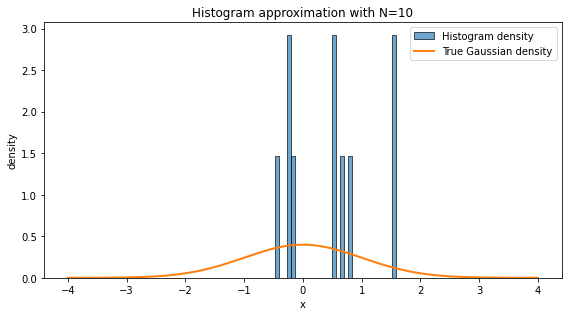

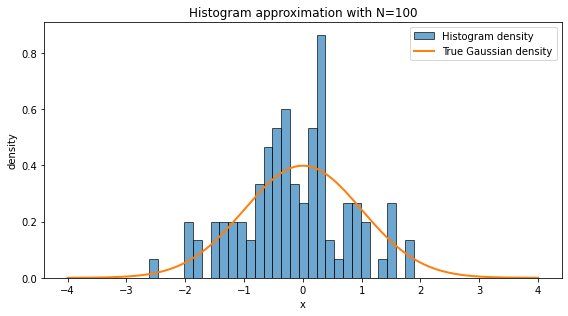

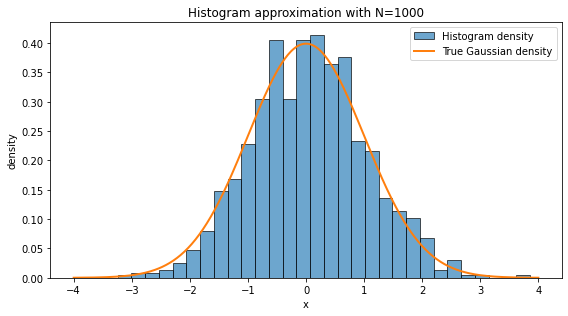

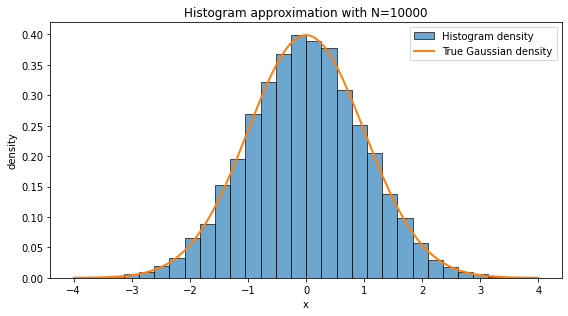

In [5]:
np.random.seed(42) # For reproducibility

for N in [10, 100, 1000, 10000]:
    data = np.random.normal(loc=0, scale=1, size=N)
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.hist(data, bins=30, density=True, alpha=0.65, edgecolor="black", label="Histogram density")

    x = np.linspace(-4, 4, 500)
    ax.plot(x, norm.pdf(x, 0, 1), linewidth=2, label="True Gaussian density")

    ax.set_title(f"Histogram approximation with N={N}")
    ax.set_xlabel("x")
    ax.set_ylabel("density")
    ax.legend(loc="best")
    plt.tight_layout()
    plt.show()

### ❓ Exercise
**Q4.** Why does the histogram with $N=10$ look so different from the histogram with $N=10000$?

## <span style="color:maroon"> Surprise, entropy and gini index </span>
### ❓ Exercise

**Q5.** If all samples belong to the same class, what is the Gini index?


In [6]:
import math

def normalize_probabilities(probabilities):
    """Return a normalized probability vector and check that it is valid."""
    probs = np.asarray(probabilities, dtype=float)
    if np.any(probs < 0):
        raise ValueError("Probabilities must be non-negative.")
    total = probs.sum()
    if total <= 0:
        raise ValueError("At least one probability must be positive.")
    return probs / total

def calculate_surprise(probability):
    """Surprise of one event, measured in bits."""
    if probability == 0:
        return float('inf')
    return -math.log2(probability)

def calculate_entropy(probabilities):
    """Shannon entropy of a probability distribution, measured in bits."""
    probs = normalize_probabilities(probabilities)
    return float(-sum(p * math.log2(p) for p in probs if p > 0))

def calculate_gini(probabilities):
    """Gini impurity of a probability distribution."""
    probs = normalize_probabilities(probabilities)
    return float(1 - np.sum(probs**2))

def plot_distribution_metrics(probabilities, title="Distribution metrics", class_names=None):
    """Plot probability, surprise, entropy, and Gini in clear separate panels.

    This version avoids overlapping labels by using separate figures and explicit spacing.
    """
    probs = normalize_probabilities(probabilities)
    n = len(probs)
    if class_names is None:
        class_names = [f"Class {i+1}" for i in range(n)]

    entropy = calculate_entropy(probs)
    gini = calculate_gini(probs)
    surprises = np.array([calculate_surprise(p) for p in probs])

    # Figure 1: probability distribution
    fig, ax = plt.subplots(figsize=(8, 4.5))
    bars = ax.bar(class_names, probs, edgecolor="black")
    ax.set_ylim(0, max(1.0, 1.15 * probs.max()))
    ax.set_ylabel("Probability")
    ax.set_title(title + "\nProbability distribution")
    ax.bar_label(bars, fmt="%.3f", padding=3)
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.show()

    # Figure 2: surprise values
    finite_surprises = surprises[np.isfinite(surprises)]
    cap = 1.0 if len(finite_surprises) == 0 else max(1.0, finite_surprises.max() + 1.0)
    plot_surprises = np.where(np.isfinite(surprises), surprises, cap)

    fig, ax = plt.subplots(figsize=(8, 4.5))
    bars = ax.bar(class_names, plot_surprises, edgecolor="black")
    ax.set_ylabel(r"Surprise, $-\log_2 p$")
    ax.set_title("Surprise of each event")
    for i, (bar, val) in enumerate(zip(bars, surprises)):
        label = r"$\infty$" if not np.isfinite(val) else f"{val:.2f}"
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), label,
                ha="center", va="bottom", fontsize=10)
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.show()

    # Figure 3: summary impurity measures
    fig, ax = plt.subplots(figsize=(6.5, 4.0))
    metric_names = ["Shannon entropy\n(bits)", "Gini impurity"]
    metric_values = [entropy, gini]
    bars = ax.bar(metric_names, metric_values, edgecolor="black")
    ax.set_title("Summary of uncertainty / impurity")
    ax.bar_label(bars, fmt="%.3f", padding=3)
    ax.set_ylim(0, max(1.0, 1.2 * max(metric_values)))
    plt.tight_layout()
    plt.show()

    print(f"Normalized probabilities: {np.round(probs, 4)}")
    print(f"Shannon entropy = {entropy:.4f} bits")
    print(f"Gini impurity   = {gini:.4f}")


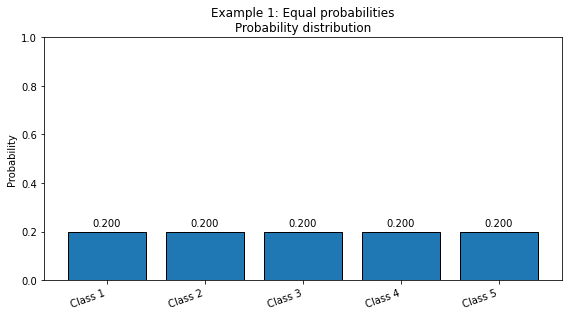

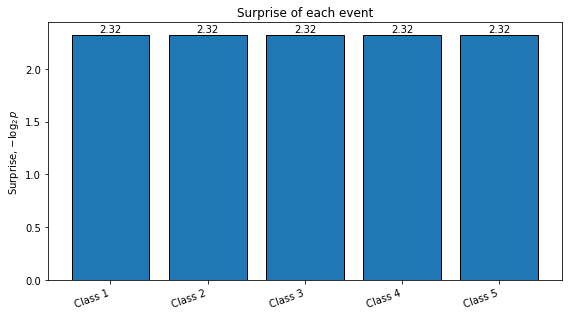

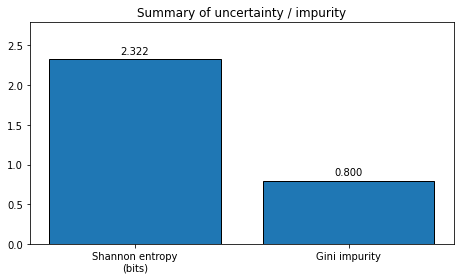

Normalized probabilities: [0.2 0.2 0.2 0.2 0.2]
Shannon entropy = 2.3219 bits
Gini impurity   = 0.8000


In [7]:
# Example 1: Equal probabilities.
# This is maximally uncertain for five classes.

probabilities_1 = [0.2, 0.2, 0.2, 0.2, 0.2]
plot_distribution_metrics(probabilities_1, title="Example 1: Equal probabilities")

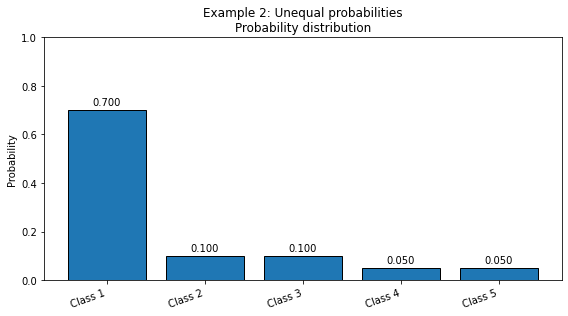

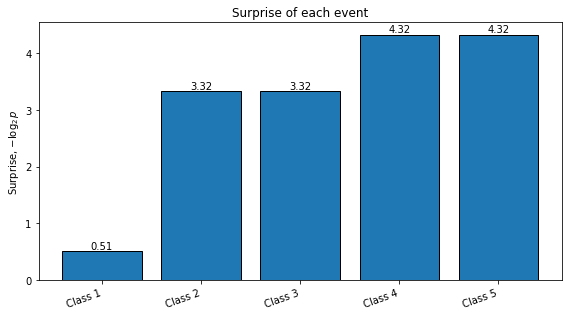

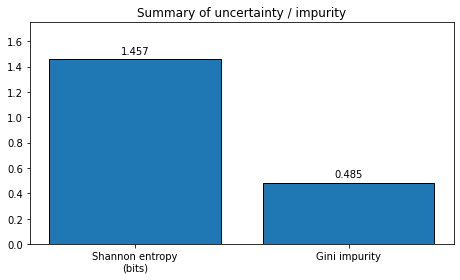

Normalized probabilities: [0.7  0.1  0.1  0.05 0.05]
Shannon entropy = 1.4568 bits
Gini impurity   = 0.4850


In [8]:
# Example 2: Unequal probabilities.
# One class dominates, so uncertainty is lower.

probabilities_2 = [0.7, 0.1, 0.1, 0.05, 0.05]
plot_distribution_metrics(probabilities_2, title="Example 2: Unequal probabilities")

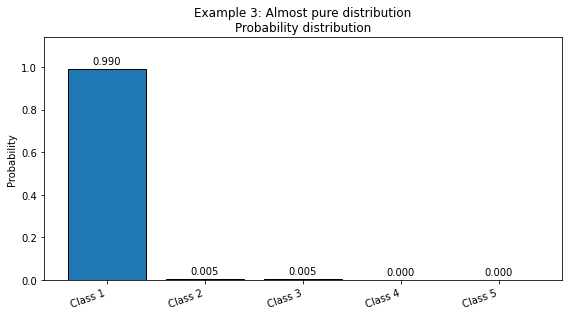

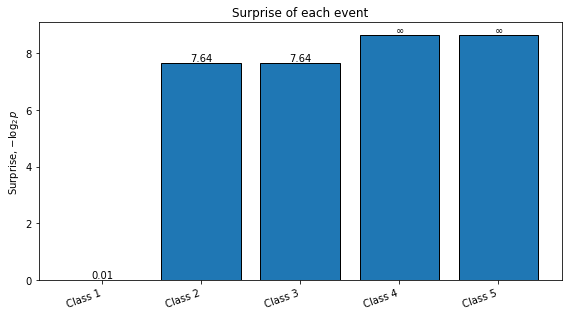

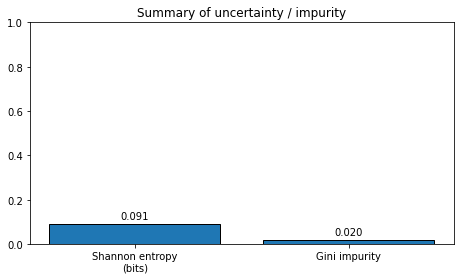

Normalized probabilities: [0.99  0.005 0.005 0.    0.   ]
Shannon entropy = 0.0908 bits
Gini impurity   = 0.0198


In [9]:
# Example 3: Almost pure distribution.
# The first class is almost certain; the zero-probability events have infinite surprise,
# but they do not contribute to entropy because p log(p) tends to zero as p -> 0.

probabilities_3 = [0.99, 0.005, 0.005, 0.0, 0.0]
plot_distribution_metrics(probabilities_3, title="Example 3: Almost pure distribution")

### ❓ Exercise

**Q6.** For different situations that you can think of, do a quantitative analysis of Gini index vs Shannon entropy.

Try at least these four probability distributions:

1. $\left[1,0,0,0\right]$ : perfectly pure.
2. $\left[0.7,0.1,0.1,0.1\right]$ : one dominant class.
3. $\left[0.4,0.3,0.2,0.1]\right]$ : moderately mixed.
4. $\left[0.25,0.25,0.25,0.25]\right]$ : maximally mixed for four classes.